In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

# Выборки
x = np.array([-1.11, -6.10, 2.42])
y = np.array([-2.29, -2.91])

# Известные дисперсии
sigma_x_sq = 2  # дисперсия первой выборки
sigma_y_sq = 1  # дисперсия второй выборки

# Размеры выборок
n = len(x)
m = len(y)

# Выборочные средние
x_bar = np.mean(x)
y_bar = np.mean(y)

## Статистика критерия

In [87]:
z_stat = (x_bar - y_bar) / np.sqrt(sigma_x_sq/n + sigma_y_sq/m)

print(f"Cтатистика: {z_stat:.4f}")

Cтатистика: 0.9289


## Критическое значение

In [88]:
alpha = 0.05

z_critical = norm.ppf(1 - alpha)

print(f"Критическое значение: delta = {z_critical:.4f}")
if z_stat > z_critical:
    print(f"Cтатистика = {z_stat:.4f} > delta = {z_critical:.4f}")
    print("→ ОТВЕРГАЕМ нулевую гипотезу H₀")
else:
    print(f"Cтатистика = {z_stat:.4f} ≤ delta = {z_critical:.4f}")
    print("→ НЕ ОТВЕРГАЕМ нулевую гипотезу H₀ (нет оснований)")

Критическое значение: delta = 1.6449
Cтатистика = 0.9289 ≤ delta = 1.6449
→ НЕ ОТВЕРГАЕМ нулевую гипотезу H₀ (нет оснований)


## График мощности критерия

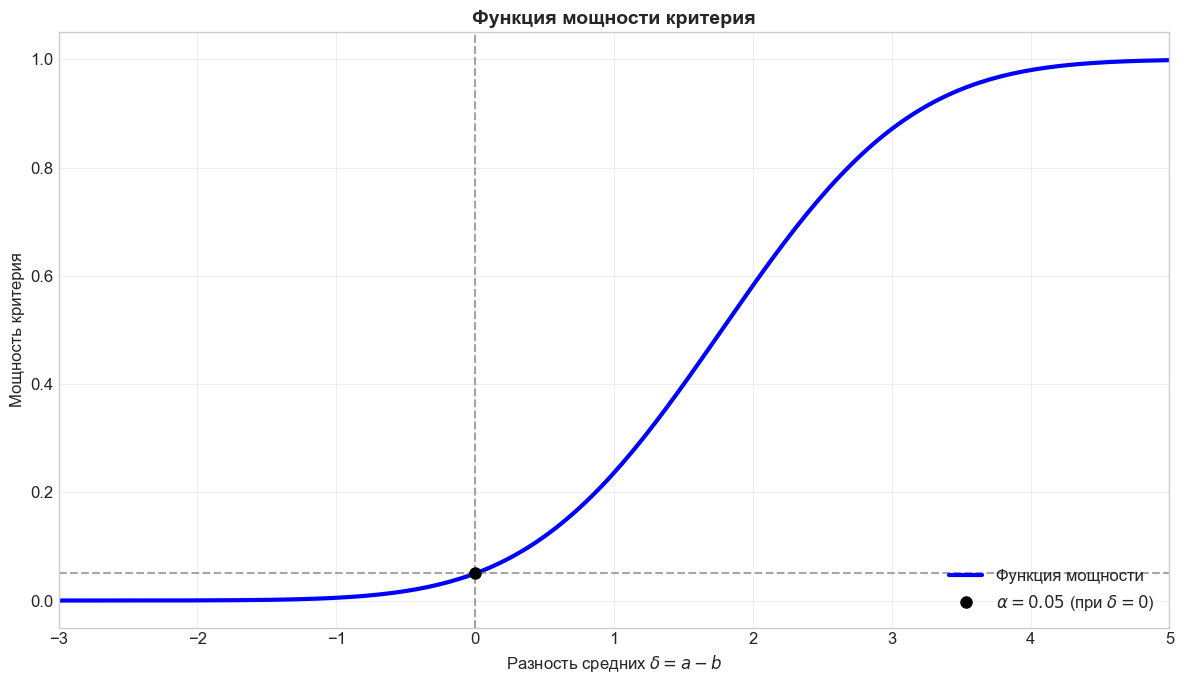

In [89]:
se = np.sqrt(sigma_x_sq/n + sigma_y_sq/m)

delta = np.linspace(-3, 5, 200)

power = 1 - norm.cdf(z_critical - delta/se)

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

ax.plot(delta, power, 'b-', linewidth=3, label='Функция мощности')

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(y=alpha, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.plot(0, alpha, 'ko', markersize=8, label=fr'$\alpha = {alpha}$ (при $\delta=0$)')

ax.set_xlabel(r'Разность средних $\delta = a - b$', fontsize=12)
ax.set_ylabel('Мощность критерия', fontsize=12)
ax.set_title('Функция мощности критерия', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([-3, 5])
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()